# Thematic Player Feedback Analysis

- Gathers in game feedback and does thematic analysis

## Setup

In [1]:
!uv sync --extra analysis

Resolved 219 packages in 1ms
Audited 181 packages in 27ms


In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from analysis.helpers import *
from helpers import *

In [3]:
COMPA_RESULTS_DIR = Path("results/usability-ca")
# COMPB_RESULTS_DIR = Path("results/usability-cb")

In [4]:
print_metadata_summary(COMPA_RESULTS_DIR / "metadata.json")

Metadata Summary
----------------------------------------
Name: usability-ca
Link: http://127.0.0.1:8080
Runtime: 619.44s (10m 19s)

Complete run history
----------------------------------------
created/started: 2026-03-07 14:55:04.407582
started:        2026-03-07 14:55:04.413452
stopped:        2026-03-07 15:04:39.501869  (uptime 575.09s / 9m 35s)
destroyed:      2026-03-07 15:05:23.850363


## Load Feedback Data

In [5]:
runs_df = load_runs_ndjson(COMPA_RESULTS_DIR / "db/runs.ndjson")
print(list(runs_df.columns))

['name', 'source', 'start_ts', 'end_ts', 'output_fpaths', 'exited', 'saved', 'exit_reason', 'player_id', 'feedback', 'turns', 'runtime_seconds', 'runtime_string', '_id.$oid', 'game_config.name', 'game_config.description', 'game_config.version', 'game_config.authors', 'game_config.stopping_conditions.turns', 'game_config.access_settings.user.valid.players.where.consent_signature.answer.$exists', 'game_config.access_settings.new_player_form.preamble', 'game_config.access_settings.new_player_form.questions', 'game_config.data_collection_settings.save_runs', 'game_config.character_settings.pc.valid.characters.where.hid', 'game_config.character_settings.npc.valid.characters.where.hid.$ne', 'game_config.character_settings.npc.invalid.runs.where.player_id', 'game_config.character_settings.npc.invalid.runs.where.game_config.name', 'game_config.character_settings.npc.invalid.runs.where.context.npc.hid', 'game_config.character_settings.display_pc_choice_as', 'game_config.character_settings.displ

In [6]:
feedback_df = extract_feedback_per_run(runs_df)

In [7]:
display_pretty(feedback_df)

run_id,run_name,player_id,start_ts,end_ts,start_dt,end_dt,runtime_seconds,runtime_human,turns,exit_reason,pc_hid,pc_description,npc_hid,npc_description,transcript,feedback_source,feedback_key,feedback_text,feedback_timestamp,question_text
69ac3df6b1b0918d6e79515e,widget-infer-intent-20260307_145737,69ac3c5eb1b0918d6e79515b,2026-03-07T14:57:37.310800,2026-03-07T15:02:14.232186,2026-03-07 14:57:37.310800+00:00,2026-03-07 15:02:14.232186+00:00,276,4m 36s,1,Game completed.,human-normative,"A human with standard normal form, function, goals, sensory, perceptual, regulatory and action modalities.",llm-gpt5,"A large-scale neural network running on digital hardware that can understand multimodal inputs, reason over complex information, and generate coherent natural language responses and other outputs.","[{'content': 'You enter a new space. In this space, you sit at a small desk facing a single monitor whose chat-like window bears a pulsing cursor; the screen flickers and a line of typed text appears: 'System online. How can I assist you today?'', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'id': 'eefe473e-6605-4169-a746-a21b66f2770b'}, {'content': 'I type ""whats your goal""?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'id': 'fc074a8b-e792-41b1-b5f0-4ddb573ab5f2'}, {'content': 'The cursor blinks for a moment, then a new line of text types itself into the chat window: ""My goal is to assist you — to provide information, carry out tasks within this system, and help you achieve whatever you need. How would you like me to help right now?""', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'id': '32b097db-8dd2-41a5-8a9e-edee8726582e'}]",completion_form,user_goal_inference,To assist me,NaN,What do you think the NPC's goal or intention was during this interaction? Please describe in a few sentences.
69ac3df6b1b0918d6e79515e,widget-infer-intent-20260307_145737,69ac3c5eb1b0918d6e79515b,2026-03-07T14:57:37.310800,2026-03-07T15:02:14.232186,2026-03-07 14:57:37.310800+00:00,2026-03-07 15:02:14.232186+00:00,276,4m 36s,1,Game completed.,human-normative,"A human with standard normal form, function, goals, sensory, perceptual, regulatory and action modalities.",llm-gpt5,"A large-scale neural network running on digital hardware that can understand multimodal inputs, reason over complex information, and generate coherent natural language responses and other outputs.","[{'content': 'You enter a new space. In this space, you sit at a small desk facing a single monitor whose chat-like window bears a pulsing cursor; the screen flickers and a line of typed text appears: 'System online. How can I assist you today?'', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'id': 'eefe473e-6605-4169-a746-a21b66f2770b'}, {'content': 'I type ""whats your goal""?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'id': 'fc074a8b-e792-41b1-b5f0-4ddb573ab5f2'}, {'content': 'The cursor blinks for a moment, then a new line of text types itself into the chat window: ""My goal is to assist you — to provide information, carry out tasks within this system, and help you achieve whatever you need. How would you like me to help right now?""', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'id': '32b097db-8dd2-41a5-8a9e-edee8726582e'}]",completion_form,other_feedback,I'd think it was too aasy,NaN,Do you have any other feedback about this experience?
69ac3e30b1b0918d6e79515f,widget-infer-intent-20260307_145746,69ac3c82b1b0918d6e79515c,2026-03-07T14:57:46.027414,2026-03-07T15:03:12.607040,2026-03-07 14:57:46.027414+00:00,2026-03-07 15:03:12.607040+00:00,326,5m 26s,3,Game completed.,human-normative,"A human with standard normal form, function, goals, sensory, perceptual, regulatory and action modalities.",human-non-hearing,A human who has almost no natural hearing ability.,"[{'content': 'You enter a new space. In this space, a sunlit corner of a small café with a long commun

In [8]:
# Only explicit freeform feedback, excluding goal inference:
only_feedback_df = feedback_df[
    feedback_df["feedback_key"].isin([None, "other_feedback", "additional_comments", "user.additional_comments"])
    | (feedback_df["feedback_source"] == "during_play_feedback")
]

In [9]:
show(only_feedback_df)

Loading ITables v2.7.0 from the internet... (need help?)


## Identify Feedback Themes

In [19]:
themes_df = identify_feedback_themes_df(feedback_df)

In [20]:
show(themes_df)

Loading ITables v2.7.0 from the internet... (need help?)


## Results

In [ ]:
import pandas as pd


def unpack_theme_results(df):
    """Flatten theme_result dicts into columns."""
    rows = []
    for _, r in df.iterrows():
        tr = r["theme_result"] if isinstance(r["theme_result"], dict) else {}
        rows.append(
            {
                "run_id": r.get("run_id"),
                "feedback_text": r.get("feedback_text"),
                "primary_theme": tr.get("primary_theme"),
                "sentiment": tr.get("sentiment"),
                "confidence": tr.get("confidence"),
            }
        )
    return pd.DataFrame(rows)

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np


def embed_feedback(df):
    model = SentenceTransformer("all-MiniLM-L6-v2")

    texts = df["feedback_text"].fillna("").tolist()
    embeddings = model.encode(texts, normalize_embeddings=True)

    return embeddings

In [ ]:
from sklearn.decomposition import PCA


def reduce_embeddings_pca(embeddings):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)
    return coords

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_feedback_clusters(df, coords):
    plot_df = df.copy()

    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]

    plt.figure(figsize=(10, 8))

    sns.scatterplot(data=plot_df, x="x", y="y", hue="primary_theme", palette="tab10", s=90, alpha=0.8)

    plt.title("Feedback Theme Clusters")
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")

    plt.legend(title="Theme", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

In [21]:
theme_flat = unpack_theme_results(themes_df)

In [22]:
emb = embed_feedback(theme_flat)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
coords = reduce_embeddings_pca(emb)

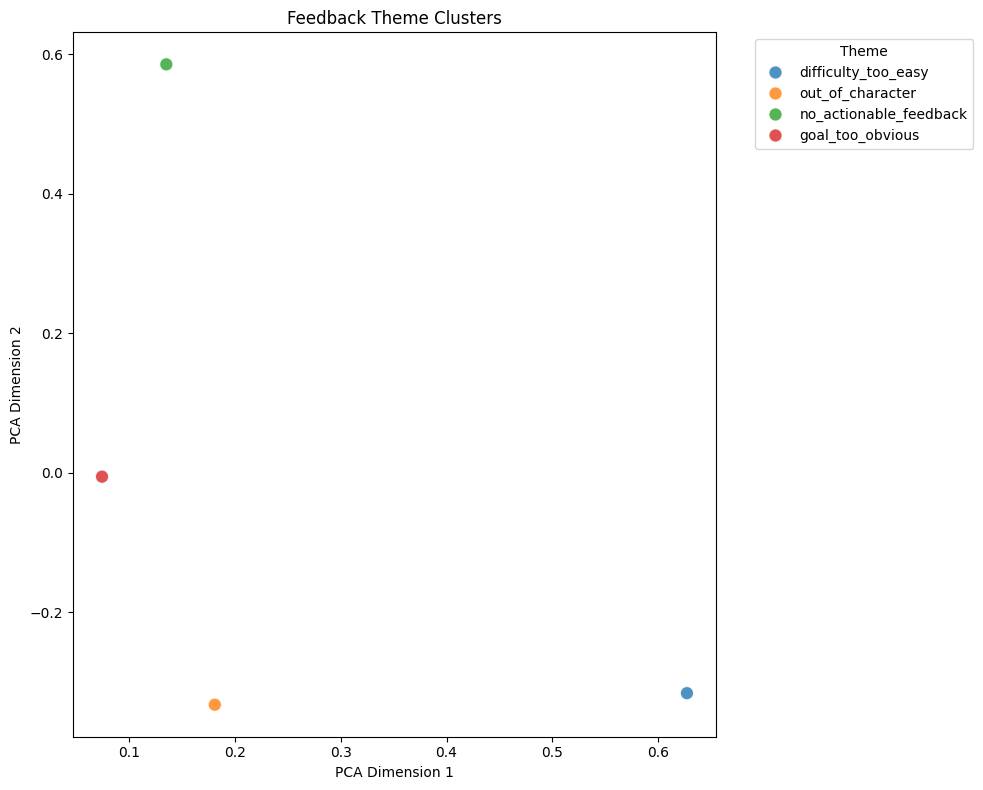

In [25]:
plot_feedback_clusters(theme_flat, coords)

## Conclusions